# Model Evaluation

This notebook evaluates the final EfficientNetV2B0 Cat, Dog, Bird, and Unknown classifier on the Official Test split created in Notebook 2.

The final model produced by Notebook 3 is loaded without retraining or changing its weights. The prepared Test images are evaluated once using the same preprocessing used during training.

Each image receives exactly one prediction using the class with the highest softmax probability.

```text
Decision rule: Highest predicted probability (argmax)
```

No confidence threshold is applied.

## 1. Runtime and Evaluation Configuration

The evaluation uses the same deterministic TensorFlow configuration as training.

Main settings:

- Random seed: 42
- Mixed-precision policy: `float32`
- Input size: 224 × 224 × 3
- Batch size: 32
- Class order: Cat, Dog, Bird, Unknown
- Preprocessing: RGB, bilinear aspect-ratio-preserving resize with padding
- Input pixel range: `[0,255]`
- Decision rule: Highest predicted probability
- Model: `Model Building/Models/Final/cat_dog_bird_unknown.keras`
- Test dataset: `Model Building/Datasets/Final Dataset/Test`
- Results directory: `Model Building/Evaluation Results`

The final Test dataset is already prepared and cleaned. This notebook only loads it, evaluates the model, and saves the resulting metrics, predictions, and confusion matrices.

In [2]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import json
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from tensorflow.keras import mixed_precision
from tqdm import tqdm


SEED = 42


gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError(
        "No GPU detected. Select the Python "
        "(Image Classifier GPU) kernel."
    )

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(
            gpu,
            True,
        )
    except RuntimeError:
        pass


tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
tf.config.experimental.enable_tensor_float_32_execution(
    False
)

mixed_precision.set_global_policy(
    "float32"
)


NOTEBOOK_DIR = Path.cwd()
MODEL_BUILDING_DIR = NOTEBOOK_DIR.parent

FINAL_DATASET_DIR = (
    MODEL_BUILDING_DIR
    / "Datasets"
    / "Final Dataset"
)

TEST_DIR = FINAL_DATASET_DIR / "Test"

FINAL_MODEL_PATH = (
    MODEL_BUILDING_DIR
    / "Models"
    / "Final"
    / "cat_dog_bird_unknown.keras"
)

RESULTS_DIR = (
    MODEL_BUILDING_DIR
    / "Evaluation Results"
)


CLASS_NAMES = [
    "Cat",
    "Dog",
    "Bird",
    "Unknown",
]

NUM_CLASSES = len(CLASS_NAMES)

IMAGE_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE


if not TEST_DIR.is_dir():
    raise FileNotFoundError(
        "The final Test directory was not found."
    )

if not FINAL_MODEL_PATH.is_file():
    raise FileNotFoundError(
        "The final model was not found."
    )

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


tf.keras.backend.clear_session()

model = tf.keras.models.load_model(
    FINAL_MODEL_PATH,
    compile=False,
)


if tuple(model.input_shape[1:]) != INPUT_SHAPE:
    raise RuntimeError(
        "The final model input shape is incorrect."
    )

if int(model.output_shape[-1]) != NUM_CLASSES:
    raise RuntimeError(
        "The final model output count is incorrect."
    )


test_dataset = (
    tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        label_mode="categorical",
        class_names=CLASS_NAMES,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        interpolation="bilinear",
        pad_to_aspect_ratio=True,
    )
)

test_file_paths = list(
    test_dataset.file_paths
)


dataset_options = tf.data.Options()
dataset_options.deterministic = True

test_dataset = test_dataset.with_options(
    dataset_options
)

test_dataset = test_dataset.prefetch(
    AUTOTUNE
)


test_class_counts = {
    class_name: sum(
        Path(file_path).parent.name == class_name
        for file_path in test_file_paths
    )
    for class_name in CLASS_NAMES
}


gpu_details = (
    tf.config.experimental.get_device_details(
        gpus[0]
    )
)


print("TensorFlow:", tf.__version__)

print(
    "GPU:",
    gpu_details.get(
        "device_name",
        "Unknown",
    ),
)

print(
    "Mixed precision:",
    mixed_precision.global_policy(),
)

print("Random seed:", SEED)
print("Deterministic operations: Enabled")
print("oneDNN custom operations: Disabled")
print("TensorFloat-32 execution: Disabled")
print()

print(
    "Model:",
    "Model Building/Models/Final/"
    "cat_dog_bird_unknown.keras",
)

print(
    "Test dataset:",
    "Model Building/Datasets/Final Dataset/Test",
)

print(
    "Decision rule:",
    "Highest predicted probability (argmax)",
)

print()

print("Official Test counts")

for class_name in CLASS_NAMES:
    print(
        f"{class_name:<10}"
        f"{test_class_counts[class_name]:>8,}"
    )

print("-" * 18)

print(
    f"{'Total':<10}"
    f"{len(test_file_paths):>8,}"
)

print()
print("Model and Test pipeline ready.")


Found 10769 files belonging to 4 classes.
TensorFlow: 2.21.0
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Mixed precision: <DTypePolicy "float32">
Random seed: 42
Deterministic operations: Enabled
oneDNN custom operations: Disabled
TensorFloat-32 execution: Disabled

Model: Model Building/Models/Final/cat_dog_bird_unknown.keras
Test dataset: Model Building/Datasets/Final Dataset/Test
Decision rule: Highest predicted probability (argmax)

Official Test counts
Cat          2,562
Dog          2,885
Bird         2,640
Unknown      2,682
------------------
Total       10,769

Model and Test pipeline ready.


## 2. Official Test Evaluation

The final model is run once across the complete Official Test dataset.

The evaluation reports:

- Overall accuracy
- Balanced accuracy
- Macro precision, recall, and F1
- Weighted precision, recall, and F1
- Per-class precision, recall, F1, and support
- Raw confusion matrix
- Confusion matrix normalized by true class
- Total inference time and average inference speed

The four class probabilities are saved for every image. The class with the highest probability is used as the final prediction, regardless of how high or low that probability is.

The evaluation outputs are saved under `Model Building/Evaluation Results`.

Evaluating Official Test: 100%|███████████████████████████████████████████████████| 337/337 [03:34<00:00,  1.57batch/s]


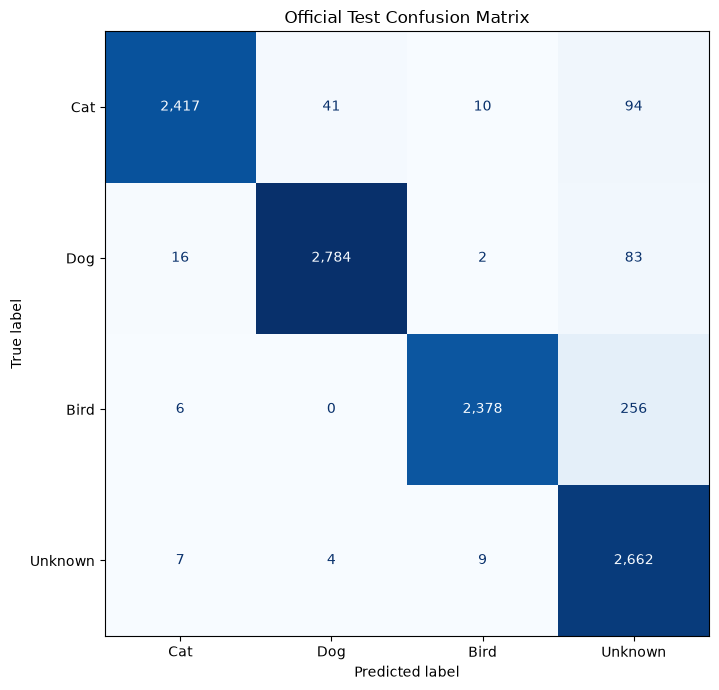

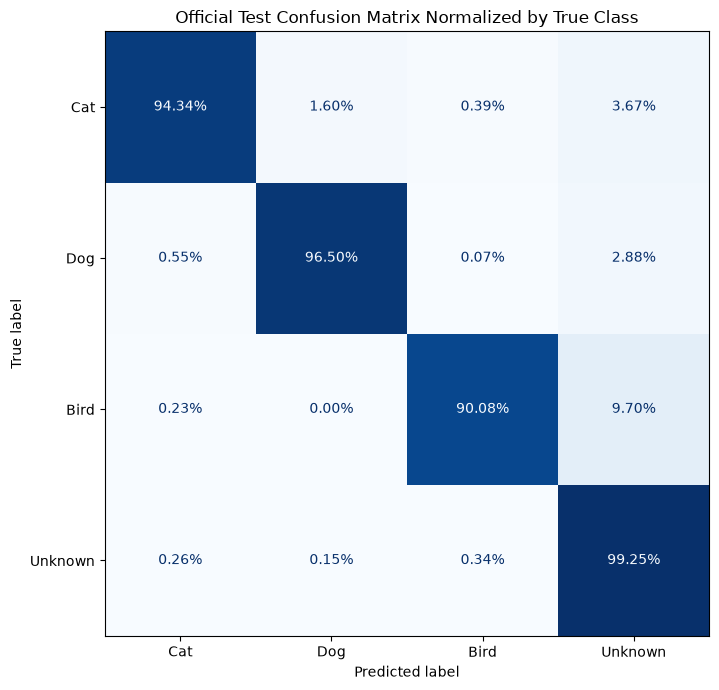

Official Test results

Images evaluated: 10,769
Overall accuracy: 95.10%
Balanced accuracy: 95.04%
Macro precision: 95.59%
Macro recall: 95.04%
Macro F1: 95.13%
Weighted precision: 95.59%
Weighted recall: 95.10%
Weighted F1: 95.16%
Evaluation time: 208.16 seconds
Average inference speed: 19.33 ms/image

Per-class results


,Class,Precision,Recall,F1,Support
0,Cat,98.81%,94.34%,96.53%,"2,562"
1,Dog,98.41%,96.50%,97.44%,"2,885"
2,Bird,99.12%,90.08%,94.38%,"2,640"
3,Unknown,86.01%,99.25%,92.16%,"2,682"



Evaluation outputs saved.
Model Building/Evaluation Results/official_test_overall_metrics.csv
Model Building/Evaluation Results/official_test_class_metrics.csv
Model Building/Evaluation Results/official_test_predictions.csv
Model Building/Evaluation Results/official_test_summary.json
Model Building/Evaluation Results/official_test_confusion_matrix.png
Model Building/Evaluation Results/official_test_confusion_matrix_normalized.png


In [4]:
total_batches = int(
    tf.data.experimental.cardinality(
        test_dataset
    ).numpy()
)


true_index_batches = []
probability_batches = []


evaluation_start = perf_counter()


for image_batch, label_batch in tqdm(
    test_dataset,
    total=total_batches,
    desc="Evaluating Official Test",
    unit="batch",
):
    batch_probabilities = model(
        image_batch,
        training=False,
    )

    batch_probabilities = tf.cast(
        batch_probabilities,
        tf.float32,
    ).numpy()

    batch_true_indices = tf.argmax(
        label_batch,
        axis=1,
        output_type=tf.int32,
    ).numpy()

    true_index_batches.append(
        batch_true_indices
    )

    probability_batches.append(
        batch_probabilities
    )


evaluation_seconds = (
    perf_counter()
    - evaluation_start
)


true_indices = np.concatenate(
    true_index_batches
)

probabilities = np.concatenate(
    probability_batches
)

predicted_indices = np.argmax(
    probabilities,
    axis=1,
)

prediction_confidences = np.max(
    probabilities,
    axis=1,
)

correct_predictions = (
    predicted_indices == true_indices
)


if len(true_indices) != len(test_file_paths):
    raise RuntimeError(
        "The prediction count does not match "
        "the number of Test images."
    )


accuracy = accuracy_score(
    true_indices,
    predicted_indices,
)

balanced_accuracy = balanced_accuracy_score(
    true_indices,
    predicted_indices,
)


macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        true_indices,
        predicted_indices,
        labels=np.arange(NUM_CLASSES),
        average="macro",
        zero_division=0,
    )
)

(
    weighted_precision,
    weighted_recall,
    weighted_f1,
    _,
) = precision_recall_fscore_support(
    true_indices,
    predicted_indices,
    labels=np.arange(NUM_CLASSES),
    average="weighted",
    zero_division=0,
)


(
    class_precision,
    class_recall,
    class_f1,
    class_support,
) = precision_recall_fscore_support(
    true_indices,
    predicted_indices,
    labels=np.arange(NUM_CLASSES),
    average=None,
    zero_division=0,
)


images_evaluated = len(
    true_indices
)

images_per_second = (
    images_evaluated
    / evaluation_seconds
)

average_milliseconds_per_image = (
    evaluation_seconds
    / images_evaluated
    * 1000
)


overall_metrics = {
    "images_evaluated": images_evaluated,
    "accuracy": float(accuracy),
    "balanced_accuracy": float(
        balanced_accuracy
    ),
    "macro_precision": float(
        macro_precision
    ),
    "macro_recall": float(
        macro_recall
    ),
    "macro_f1": float(
        macro_f1
    ),
    "weighted_precision": float(
        weighted_precision
    ),
    "weighted_recall": float(
        weighted_recall
    ),
    "weighted_f1": float(
        weighted_f1
    ),
    "mean_prediction_confidence": float(
        prediction_confidences.mean()
    ),
    "evaluation_seconds": float(
        evaluation_seconds
    ),
    "images_per_second": float(
        images_per_second
    ),
    "average_milliseconds_per_image": float(
        average_milliseconds_per_image
    ),
}


overall_metrics_frame = pd.DataFrame(
    [
        {
            "Metric": metric_name,
            "Value": metric_value,
        }
        for metric_name, metric_value
        in overall_metrics.items()
    ]
)


class_metrics_frame = pd.DataFrame(
    {
        "Class": CLASS_NAMES,
        "Precision": class_precision,
        "Recall": class_recall,
        "F1": class_f1,
        "Support": class_support.astype(int),
    }
)


prediction_records = {
    "image_path": [
        Path(file_path)
        .relative_to(
            MODEL_BUILDING_DIR.parent
        )
        .as_posix()
        for file_path in test_file_paths
    ],
    "true_class": [
        CLASS_NAMES[class_index]
        for class_index in true_indices
    ],
    "predicted_class": [
        CLASS_NAMES[class_index]
        for class_index in predicted_indices
    ],
    "correct": correct_predictions,
    "prediction_confidence": (
        prediction_confidences
    ),
}


for class_index, class_name in enumerate(
    CLASS_NAMES
):
    prediction_records[
        f"{class_name.lower()}_probability"
    ] = probabilities[:, class_index]


predictions_frame = pd.DataFrame(
    prediction_records
)


confusion = confusion_matrix(
    true_indices,
    predicted_indices,
    labels=np.arange(NUM_CLASSES),
)

normalized_confusion = confusion_matrix(
    true_indices,
    predicted_indices,
    labels=np.arange(NUM_CLASSES),
    normalize="true",
)


OVERALL_METRICS_PATH = (
    RESULTS_DIR
    / "official_test_overall_metrics.csv"
)

CLASS_METRICS_PATH = (
    RESULTS_DIR
    / "official_test_class_metrics.csv"
)

PREDICTIONS_PATH = (
    RESULTS_DIR
    / "official_test_predictions.csv"
)

SUMMARY_PATH = (
    RESULTS_DIR
    / "official_test_summary.json"
)

CONFUSION_MATRIX_PATH = (
    RESULTS_DIR
    / "official_test_confusion_matrix.png"
)

NORMALIZED_CONFUSION_MATRIX_PATH = (
    RESULTS_DIR
    / "official_test_confusion_matrix_normalized.png"
)


overall_metrics_frame.to_csv(
    OVERALL_METRICS_PATH,
    index=False,
)

class_metrics_frame.to_csv(
    CLASS_METRICS_PATH,
    index=False,
)

predictions_frame.to_csv(
    PREDICTIONS_PATH,
    index=False,
)


summary = {
    "dataset": {
        "name": "Official Open Images V7 Test",
        "path": (
            "Model Building/Datasets/"
            "Final Dataset/Test"
        ),
        "class_names": CLASS_NAMES,
        "class_counts": test_class_counts,
        "images_evaluated": images_evaluated,
    },
    "model": {
        "path": (
            "Model Building/Models/Final/"
            "cat_dog_bird_unknown.keras"
        ),
        "input_shape": list(INPUT_SHAPE),
        "output_classes": NUM_CLASSES,
    },
    "preprocessing": {
        "colour_mode": "RGB",
        "resize_method": (
            "Bilinear aspect-ratio-preserving "
            "resize with padding"
        ),
        "input_size": list(IMAGE_SIZE),
        "input_pixel_range": "[0,255]",
        "efficientnet_preprocessing": (
            "Included inside the model"
        ),
    },
    "prediction": {
        "decision_rule": (
            "Highest predicted probability (argmax)"
        ),
        "confidence_threshold": None,
    },
    "metrics": overall_metrics,
    "class_metrics": (
        class_metrics_frame.to_dict(
            orient="records"
        )
    ),
    "runtime": {
        "tensorflow_version": tf.__version__,
        "random_seed": SEED,
        "mixed_precision_policy": (
            mixed_precision.global_policy().name
        ),
        "deterministic_operations": True,
        "oneDNN_custom_operations": False,
        "tensorfloat_32_execution": False,
    },
}


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as summary_file:
    json.dump(
        summary,
        summary_file,
        indent=4,
    )


figure, axis = plt.subplots(
    figsize=(8, 7)
)

ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=CLASS_NAMES,
).plot(
    ax=axis,
    values_format=",d",
    cmap="Blues",
    colorbar=False,
)

axis.set_title(
    "Official Test Confusion Matrix"
)

figure.tight_layout()

figure.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close(
    figure
)


figure, axis = plt.subplots(
    figsize=(8, 7)
)

ConfusionMatrixDisplay(
    confusion_matrix=normalized_confusion,
    display_labels=CLASS_NAMES,
).plot(
    ax=axis,
    values_format=".2%",
    cmap="Blues",
    colorbar=False,
)

axis.set_title(
    "Official Test Confusion Matrix "
    "Normalized by True Class"
)

figure.tight_layout()

figure.savefig(
    NORMALIZED_CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

plt.close(
    figure
)


print("Official Test results")
print()

print(
    "Images evaluated:",
    f"{images_evaluated:,}",
)

print(
    "Overall accuracy:",
    f"{accuracy:.2%}",
)

print(
    "Balanced accuracy:",
    f"{balanced_accuracy:.2%}",
)

print(
    "Macro precision:",
    f"{macro_precision:.2%}",
)

print(
    "Macro recall:",
    f"{macro_recall:.2%}",
)

print(
    "Macro F1:",
    f"{macro_f1:.2%}",
)

print(
    "Weighted precision:",
    f"{weighted_precision:.2%}",
)

print(
    "Weighted recall:",
    f"{weighted_recall:.2%}",
)

print(
    "Weighted F1:",
    f"{weighted_f1:.2%}",
)

print(
    "Evaluation time:",
    f"{evaluation_seconds:.2f} seconds",
)

print(
    "Average inference speed:",
    f"{average_milliseconds_per_image:.2f} ms/image",
)

print()

print("Per-class results")

display(
    class_metrics_frame.style.format(
        {
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
            "F1": "{:.2%}",
            "Support": "{:,}",
        }
    )
)

print()
print("Evaluation outputs saved.")

for output_path in [
    OVERALL_METRICS_PATH,
    CLASS_METRICS_PATH,
    PREDICTIONS_PATH,
    SUMMARY_PATH,
    CONFUSION_MATRIX_PATH,
    NORMALIZED_CONFUSION_MATRIX_PATH,
]:
    print(
        output_path.relative_to(
            MODEL_BUILDING_DIR.parent
        ).as_posix()
    )